## Individual Assignment 2 - Hotel Bookings Dataset ##

<b>Name</b>: Sean Holiday

<b>Group Number</b>: 19

<b>Group Name</b>: LI

<b>Group Members</b>: Sean, Isabelle, Lily, Yogya 

### Methods & Plans

#### Reviewed Question

**Old Question:** To what extent can a predictive model using lead time, guest history, and deposit type accurately determine the probability of a booking cancellation in both resort and city hotel environments?

**Updated Question:**: To what extent can a predictive model using guest demographics and booking details accurately determine the probability of a booking cancellation in both resort and city hotel environments?

I changed the question to the version it is currently, because I wanted to focus more on a guest's details. Furthermore, from additional EDA (described in later section) I found that `deposit_type` should not be used as a feature because every guest whose deposit is "Non Refundable" will **always** not cancel their booking!

#### Proposed Method

To answer this prediction question, I will use a **logistic regression model** that will be implemented using variables selected through stepAIC via backward selection. I selected backward over forward selection due to the fact that the number of observations in the dataset is significantly larger than the number of features (The dataset contains 1000 observations with 33 features in total). 

With regards to the variable selectio nmethod, I did not opt to pick LASSO because 13 features of the dataset are by nature categorical. This would include features such as `customer_type`, `is_previous_customer` and `market_segment` and other categorical features are expected to be strong indicators of whether a guest cancels.

After model construction with the selected features, I will use a confusion matrix to evaluate classification performance, specifically precision and recall. It is worth noting that logistic regression performance is sensitive to the chosen classification threshold. Therefore, an AUC-ROC curve will also be generated to provide a threshold-independent evaluation of the model.

#### Assumptions & Limitations

- **Independence:** A key assumption of logistic regression is that observations are independent of one another. In this dataset, this assumption may be violated if the same guest appears multiple times across different bookings, as their cancellation behaviour would be correlated across entries. Unfortunately, the dataset contains no reference to a guest's ID or reference number (due to privacy reasons), so this limitation may not be confirmable.

- **Multicollinearity:** Logistic regression also assumes little to no multicollinearity among predictors. Features such as `lead_time` and `deposit_type` may be correlated. Conventionally, guests who book far in advance are more likely to pay a deposit which could inflate standard errors and reduce the reliability of coefficient estimates. To find multicollinearity for any feature, the `vif` function will be used.

- **Residuals:** Regarding residual diagnostics, raw residuals cannot be used to assess model fit in logistic regression as they are in linear regression. Instead, Pearson residuals or deviance residuals must be used to evaluate whether the model fits the data adequately.

- **Response (Target):** The response variable `is_canceled` (whether a booking was cancelled) is binary, which satisfies the assumption of logistic regression. However, class imbalance may be a limitation if cancellations are significantly rarer than non-cancellations, as the model may be biased toward predicting the majority class. Previously from individual assignment 1, `is_canceled` was found to be slightly imbalanced, where only 36.6% of the data contained booking cancellation instances. Although this is not a severe class imbalance, stratified sampling will be used during the train-test split to ensure the training data contains a representative proportion of cancellations. To mitigate this issue we can use stratified sampling when creating the train-test split.

- **Confounding variables not included in the dataset:** Finally, while the model may achieve strong predictive performance, causal interpretations should be made cautiously. Confounding factors such as seasonal demand, hotel policies, or economic conditions are not captured in the dataset and may influence both the predictors and the likelihood of cancellation.

### Implementation (Coding Section)

#### Libraries

In [205]:
#Libraries
library(MASS)
library(broom)
library(tidymodels)
library(repr)
library(mltools)
library(leaps)
library(tidyverse)
library(modelr)
library(dplyr)
library(rsample)
library(car)
library(pROC)

#### Loading Dataset

When loading the dataset I also made the decision to remove some features because they may have little or detrimental effect to predicting cancellation:

- `rownames`: just an index identifier, carries no predictive information
- `reservation_status`: directly encodes whether a booking was cancelled (e.g. "Cancelled", "Check-Out"), making it a leaky variable that would perfectly predict the outcome
- `reservation_status_date`: the date the reservation status was last changed, also leaky for the same reason as above
- `arrival_date_week_number`: redundant with arrival_date_month which already captures seasonality
- `meal`: meal plan type is not directly related to cancellation behaviour and is not central to the research question
- `reserved_room_type`: the room type code is too granular and not meaningful for predicting cancellations
- `country`: too many unique values which would create too many dummy variables and reduce model stability
- `assigned_room_type`: the room actually assigned may differ from the reserved room, making it potentially leaky as it is determined at check-in
- `arrival_date_year`: not useful for prediction as we are not interested in year-specific trends
- `arrival_date_day_of_month`: too granular and unlikely to have a meaningful relationship with cancellations
- `deposit_type`: this feature perfectly predicts `is_canceled` when the value is "non-refundable (uncomment the code below to see)

In [206]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv"

#Removed features not relevant or detrimental to predicting is_canceled
hotel_bookings <- read_csv(url) %>% 
    dplyr::select(-rownames, 
                  -reservation_status, 
                  -reservation_status_date, 
                  -arrival_date_week_number, 
                  -meal, 
                  -reserved_room_type, 
                  -country,
                  -assigned_room_type,
                  -arrival_date_year,
                  -arrival_date_day_of_month,
                  -deposit_type)

Rows: 1000 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): hotel, arrival_date_month, meal, country, market_segment, distrib...
dbl  (19): rownames, is_canceled, lead_time, arrival_date_year, arrival_date...
date  (1): reservation_status_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [207]:
# Uncomment to see that guests with a non-refunable 
# deposit type will always not cancel their hotel booking

# eda_hotel_bookings <- read_csv(url) %>% select(deposit_type, is_canceled)

# eda_hotel_bookings$deposit_type <- as.factor(eda_hotel_bookings$deposit_type)
# eda_hotel_bookings$is_canceled <- as.integer(eda_hotel_bookings$is_canceled)

# deposit_cancel_rate <- eda_hotel_bookings %>%
#     select(is_canceled, deposit_type) %>%
#     group_by(deposit_type) %>%
#     summarize(prop_cancellation = sum(is_canceled)/n())

# deposit_cancel_rate

#### Sneak-peek at Data

In [208]:
head(hotel_bookings)

hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,⋯,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
City Hotel,1,1,September,0,2,1,0,0,Offline TA/TO,⋯,1,0,0,50,NULL,0,Transient,98.10,0,0
Resort Hotel,1,19,March,2,4,2,0,0,Online TA,⋯,0,0,0,240,NULL,0,Transient,70.17,0,1
Resort Hotel,0,9,August,0,4,2,0,0,Online TA,⋯,0,0,0,241,NULL,0,Transient,193.40,0,1
Resort Hotel,0,110,November,0,1,2,0,0,Online TA,⋯,0,0,2,314,NULL,0,Transient,36.24,1,0
City Hotel,0,329,July,0,2,2,0,0,Online TA,⋯,0,0,0,9,NULL,0,Transient,89.10,0,1
Resort Hotel,0,212,August,2,8,2,1,0,Offline TA/TO,⋯,0,0,1,143,NULL,0,Transient,89.75,0,0


#### Cleaning Data

In [209]:
# Mutate agent and company features so no NA values
hotel_bookings <- hotel_bookings %>%
    mutate(agent = ifelse(agent == "NULL", 0, agent),
           company = ifelse(company == "NULL", 0, company))

# Make agent and company feature into a boolean feature
# The ID of the agent and company are not as important to predict is_canceled
# But whether the booking was made through an agent or company may be
# an indicator of cancellation behaviour

hotel_bookings <- hotel_bookings %>%
    mutate(agent = ifelse(agent > 0, 1, 0),
           company = ifelse(company > 0, 1, 0))

# Change char/string features into a factor feature (especially target)
hotel_bookings$customer_type <- as.factor(hotel_bookings$customer_type)
hotel_bookings$arrival_date_month <- as.factor(hotel_bookings$arrival_date_month)
hotel_bookings$hotel <- as.factor(hotel_bookings$hotel)
hotel_bookings$distribution_channel <- as.factor(hotel_bookings$distribution_channel)
hotel_bookings$is_repeated_guest <- as.integer(hotel_bookings$is_repeated_guest)
hotel_bookings$market_segment <- as.factor(hotel_bookings$market_segment)
hotel_bookings$agent <- as.integer(hotel_bookings$agent)
hotel_bookings$company <- as.integer(hotel_bookings$company)

# Change target feature into boolean 
hotel_bookings$is_canceled <- as.integer(hotel_bookings$is_canceled)

glimpse(hotel_bookings)

Rows: 1,000
Columns: 22
$ hotel                          <fct> City Hotel, Resort Hotel, Resort Hotel,…
$ is_canceled                    <int> 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, …
$ lead_time                      <dbl> 1, 19, 9, 110, 329, 212, 14, 58, 88, 37…
$ arrival_date_month             <fct> September, March, August, November, Jul…
$ stays_in_weekend_nights        <dbl> 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1, …
$ stays_in_week_nights           <dbl> 2, 4, 4, 1, 2, 8, 0, 5, 3, 3, 1, 1, 1, …
$ adults                         <dbl> 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, …
$ children                       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, …
$ babies                         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ market_segment                 <fct> Offline TA/TO, Online TA, Online TA, On…
$ distribution_channel           <fct> TA/TO, TA/TO, TA/TO, TA/TO, TA/TO, TA/T…
$ is_repeated_guest              <int> 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, …
$ previous_cance

#### Train & Test Split

In [210]:
# For reproducibility
set.seed(301)

split <- initial_split(hotel_bookings, prop = 0.8, strata = is_canceled)
train <- training(split)
test <- testing(split)

In [211]:
lr_model <- glm(is_canceled ~ ., data = train, family = "binomial")

tidy(lr_model)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),5.240965e-02,1.951201e+00,0.026860206,9.785712e-01
hotelResort Hotel,-4.247847e-01,2.240859e-01,-1.895633280,5.800855e-02
lead_time,5.895217e-03,1.162251e-03,5.072240095,3.931599e-07
arrival_date_monthAugust,-8.627717e-01,4.508664e-01,-1.913586251,5.567304e-02
arrival_date_monthDecember,-7.081179e-01,4.909028e-01,-1.442480857,1.491668e-01
arrival_date_monthFebruary,-2.609564e-01,5.102837e-01,-0.511394713,6.090747e-01
arrival_date_monthJanuary,-2.150580e-01,5.196832e-01,-0.413825277,6.790021e-01
arrival_date_monthJuly,-5.223022e-01,4.211877e-01,-1.240070016,2.149495e-01
arrival_date_monthJune,-2.533107e-01,4.333370e-01,-0.584558221,5.588448e-01


### Multicolinearity

Since our dataset contains categorical features, the Generalized Variance Inflation Factor (GVIF) is used to assess multicollinearity. To account for differing degrees of freedom across variables, `GVIF^(1/(2*Df))` is used as the primary metric, where values above 2 indicate potential multicollinearity. Based on this threshold, `previous_cancellation`s and `previous_bookings_not_canceled` were flagged. Since these two features capture overlapping information about a guest's booking history, `previous_bookings_not_canceled` will be removed prior to model construction to mitigate this issue.

In [212]:
VIF_model <- vif(lr_model)

round(VIF_model, 3)

,GVIF,Df,GVIF^(1/(2*Df))
hotel,1.191,1,1.091
lead_time,1.413,1,1.189
arrival_date_month,2.461,11,1.042
stays_in_weekend_nights,1.309,1,1.144
stays_in_week_nights,1.343,1,1.159
adults,1.280,1,1.131
children,1.177,1,1.085
babies,1.000,1,1.000
market_segment,55.416,5,1.494
distribution_channel,18.561,3,1.627


### stepAIC (Variable Reduction)

After running `stepAIC` in a backward direction, we are left with only 18 features (including feature levels)

In [213]:
lr_model <- glm(is_canceled ~ . - previous_bookings_not_canceled, data = train, family = "binomial")


# Had to use suppressWarnings function, otherwise there will be a long list of the warning message below
step_model <- suppressWarnings(stepAIC(lr_model, direction = "backward", trace = FALSE))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


In [214]:
# Summary os stepAIC's selected model
hotel_bookings_backward_summary <- summary(step_model)
hotel_bookings_backward_summary


Call:
glm(formula = is_canceled ~ hotel + lead_time + adults + children + 
    babies + market_segment + previous_cancellations + booking_changes + 
    customer_type + average_daily_rate + required_car_parking_spaces + 
    total_of_special_requests, family = "binomial", data = train)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                  -2.093e+00  1.420e+00  -1.474 0.140429    
hotelResort Hotel            -5.827e-01  2.067e-01  -2.819 0.004825 ** 
lead_time                     5.465e-03  1.042e-03   5.245 1.57e-07 ***
adults                        3.261e-01  1.965e-01   1.659 0.097016 .  
children                      4.032e-01  2.335e-01   1.727 0.084129 .  
babies                       -1.690e+01  2.164e+03  -0.008 0.993771    
market_segmentCorporate      -1.222e+00  1.319e+00  -0.926 0.354202    
market_segmentDirect         -1.971e+00  1.261e+00  -1.563 0.117946    
market_segmentGroups          1.221e-01  1.238e+0

In [215]:
# To derive the formula to build our optimal model
hotel_formula <- formula(step_model)

hotel_formula

is_canceled ~ hotel + lead_time + adults + children + babies + 
    market_segment + previous_cancellations + booking_changes + 
    customer_type + average_daily_rate + required_car_parking_spaces + 
    total_of_special_requests

In [216]:
# Using the formula to build our optimal model
hotel_lr_model <- glm(formula = hotel_formula,
                      data = train,
                      family = "binomial")

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


### Visualization

#### Confusion Matrix

The confusion matrix reveals that the model correctly classified 152 out of 201 bookings, yielding an overall accuracy of 75.6%. In terms of cancellation detection, the model achieved a precision of 70.5% ` = 43 / (43 + 18)` and a recall of 58.1% = `43 / (43 + 31)`, meaning that while it is reasonably accurate when it does predict a cancellation, it misses a portion of actual cancellations (31 false negatives). This suggests the model is more cautious in predicting cancellations, favouring non-cancellation predictions. In a hotel business context, these missed cancellations could be costly as they prevent the hotel from taking proactive measures to fill those rooms.

In [217]:
# Generating our confusion matrix with the threshold defined at 0.5
predictions <- predict(hotel_lr_model, newdata = test, type = "response")
predicted_class <- ifelse(predictions > 0.5, 1, 0)
confusion_matrix <- table(Predicted = predicted_class, Actual = test$is_canceled)
confusion_matrix

         Actual
Predicted   0   1
        0 110  31
        1  17  43

#### ROC Curve

The ROC curve demonstrates that the model performs better than random chance (the diagonal line represents a random classifier with AUC = 0.5). With an AUC of 0.795, the model has a 79.5% probability of correctly distinguishing between a cancelled and non-cancelled booking. The curve rises steeply in the early portion (high specificity region), indicating that the model can identify a good proportion of true cancellations while keeping the false positive rate low. Overall, an AUC of 0.795 reflects moderate to good discriminative ability, suggesting the model is effective at predicting booking cancellations across classification thresholds.

Setting levels: control = 0, case = 1

Setting direction: controls < cases



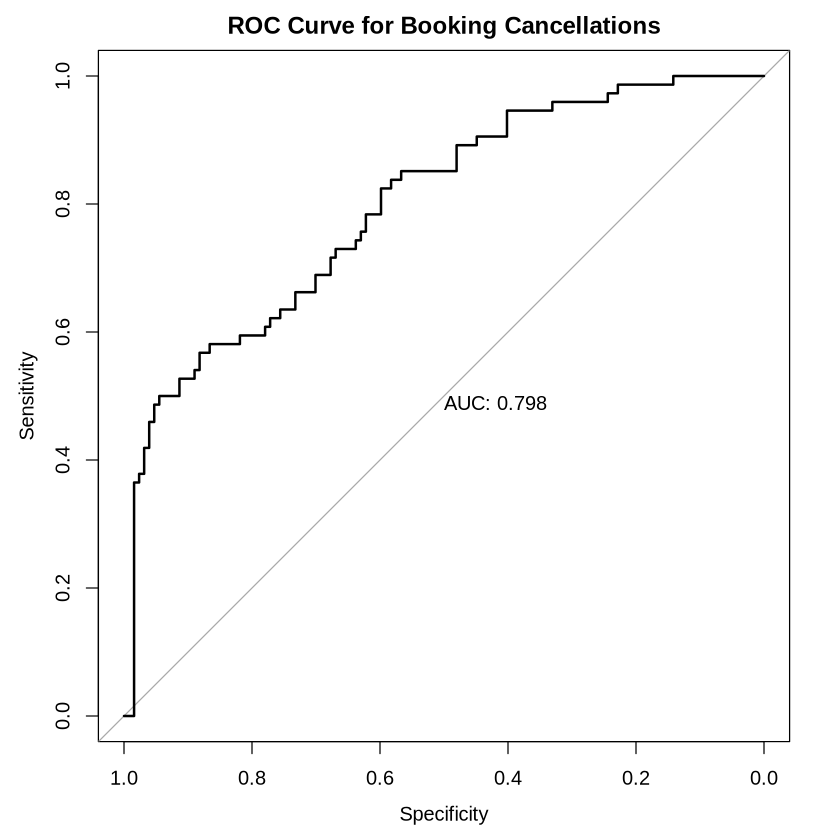

In [218]:
# Generate ROC curve to see the balance between specificity and sensitivity and different threshold levels
roc_curve <- roc(test$is_canceled, predictions)

plot(roc_curve, main = "ROC Curve for Booking Cancellations", print.auc = TRUE)


### AI Tool Disclosure

Claude AI was  used to figure out the necessary function calls, fix debug issues, and assist with understanding GVIF in comparison to base VIF. Any creative task for this assignment (question formation, data research, visualization selection) was done strictly <b>WITHOUT</b> any AI tools.  